In [5]:
'''!apt-get install libssl-dev > /dev/null
!wget https://repo.continuum.io/miniconda/Miniconda3-latest-Linux-x86_64.sh
!chmod +x ./Miniconda3-latest-Linux-x86_64.sh
!./Miniconda3-latest-Linux-x86_64.sh -b -p /conda  > /dev/null 2>&1
!/conda/bin/conda install -c r r-rstan r-irkernel r-islr gxx_linux-64 -y -q > /dev/null 2>&1
!/conda/bin/R -e "IRkernel::installspec(name = 'python2', displayname = 'R', user = FALSE)"  > /dev/null 2>&1
!mkdir /root/.R/
!echo "CXX14FLAGS=-O3 -mtune=native -march=native -Wno-ignored-attributes -Wno-deprecated-declarations" > /root/.R/Makevars
import os
os._exit(00)'''

'!apt-get install libssl-dev > /dev/null\n!wget https://repo.continuum.io/miniconda/Miniconda3-latest-Linux-x86_64.sh\n!chmod +x ./Miniconda3-latest-Linux-x86_64.sh\n!./Miniconda3-latest-Linux-x86_64.sh -b -p /conda  > /dev/null 2>&1\n!/conda/bin/conda install -c r r-rstan r-irkernel r-islr gxx_linux-64 -y -q > /dev/null 2>&1\n!/conda/bin/R -e "IRkernel::installspec(name = \'python2\', displayname = \'R\', user = FALSE)"  > /dev/null 2>&1\n!mkdir /root/.R/\n!echo "CXX14FLAGS=-O3 -mtune=native -march=native -Wno-ignored-attributes -Wno-deprecated-declarations" > /root/.R/Makevars\nimport os\nos._exit(00)'

In [6]:
%load_ext rpy2.ipython

In [7]:
%%R
Sys.setenv(PATH= paste("/conda/bin" , Sys.getenv("PATH"), sep = ":" ) )
install.packages('ggmap', repos='http://cran.rstudio.com/')

install.packages('codetools', repos='http://cran.rstudio.com/')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.rstudio.com/src/contrib/ggmap_4.0.2.tar.gz'
Content type 'application/x-gzip' length 4966322 bytes (4.7 MB)
downloaded 4.7 MB


The downloaded source packages are in
	‘/tmp/RtmpDuTi9p/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.rstudio.com/src/contrib/codetools_0.2-20.tar.gz'
Content type 'application/x-gzip' length 38683 bytes (37 KB)
downloaded 37 KB


The downloaded source packages are in
	‘/tmp/RtmpDuTi9p/downloaded_packages’


In [8]:
%%R
# Instructions:  Paste each block of code into R, one at a time, to see what it does;

# Simple linear regression (SLR)

# Load package ISLR into your current R session;

library(ISLR);

In [9]:
%%R

# Attach the Carseats dataset to the current R session so that R will recognize the names of its variables (columns);

attach(Carseats);

In [10]:
%%R

# Show scatter plot;

# Install ggplot2 graphingpackage if it is not currently installed;

if (!require(ggplot2)) install.packages("ggplot2");

Loading required package: ggplot2


In [11]:
%%R

# Load ggplot2 package into your current R session;

library(ggplot2);

In addition: Warning message:
`qplot()` was deprecated in ggplot2 3.4.0.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


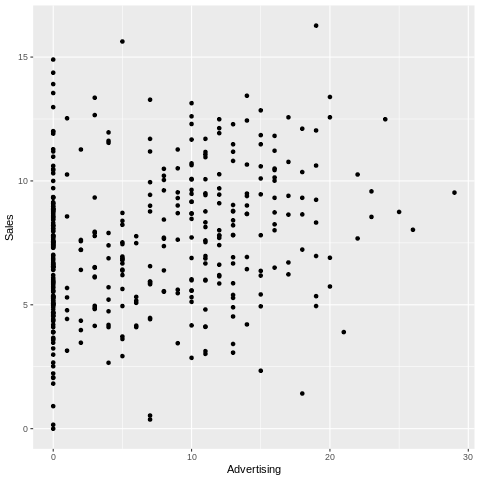

In [12]:
%%R

# Create scatter plot of Sales vs. Advertising using ggplot2;

qplot(Advertising, Sales);

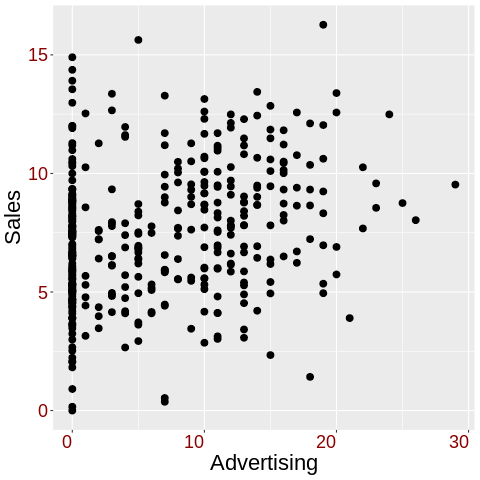

In [13]:
%%R

# Create better-looking scatter plot with optional arguments;

qplot(Advertising, Sales) + theme(axis.title.y = element_text(size = rel(2), angle = 90)) + theme(axis.title.x = element_text(size = rel(2), angle = 0))+ theme(axis.text.x = element_text(angle = 0, hjust = 1, size=18,color="darkred")) +  theme(axis.text.y = element_text(angle = 0, hjust = 1, size=18,color="darkred")) + geom_point(size = 3);

`geom_smooth()` using formula = 'y ~ x'


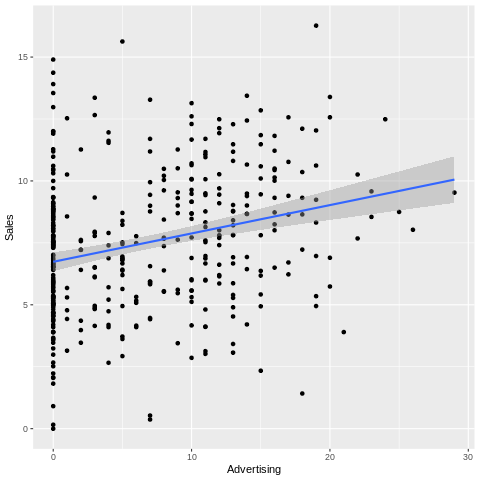

In [14]:
%%R

# Show scatter plot with simple linear regression (SLR) line;

# Create simple scatter plot and regression line of Sales vs. Advertising using ggplot2;

qplot(Advertising, Sales) + geom_smooth(method = lm) ;

`geom_smooth()` using formula = 'y ~ x'


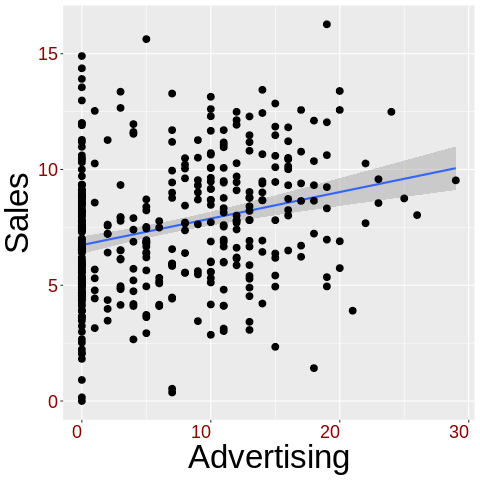

In [15]:
# Create better-looking plot with optional arguments;
%%R

qplot(Advertising, Sales) + geom_smooth(method = lm) + theme(axis.title.y = element_text(size = rel(3), angle = 90)) + theme(axis.title.x = element_text(size = rel(3), angle = 0))+ theme(axis.text.x = element_text(angle = 0, hjust = 1, size=18,color="darkred")) +  theme(axis.text.y = element_text(angle = 0, hjust = 1, size=18,color="darkred")) + geom_point(size = 3);

`geom_smooth()` using formula = 'y ~ x'


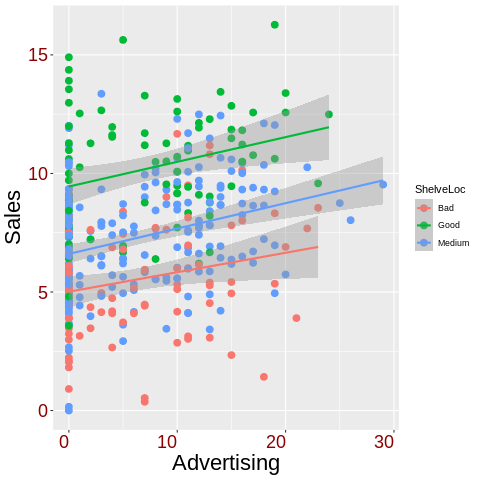

In [16]:
# Scatter plot with color and simple linear regression (SLR) lines;

# Create scatter plot and regression lines of Sales vs. Advertising by shelf location;
%%R

qplot(Advertising, Sales, color = ShelveLoc) + theme(axis.title.y = element_text(size = rel(2), angle = 90)) + theme(axis.title.x = element_text(size = rel(2), angle = 0))+ theme(axis.text.x = element_text(angle = 0, hjust = 1, size=18,color="darkred")) +  theme(axis.text.y = element_text(angle = 0, hjust = 1, size=18,color="darkred")) + geom_point(size = 3) + geom_smooth(method = "lm");

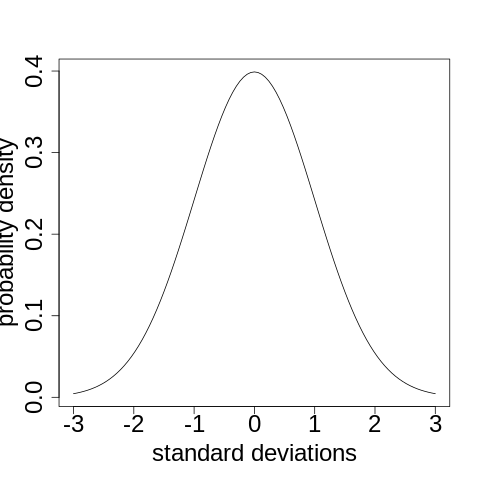

In [17]:
# Plot normal probability density function (PDF);

%%R


plot(dnorm,-3,3, xlab = "standard deviations", ylab = "probability density", cex = 1.1, cex.lab = 2, cex.axis = 2,cex.main = 1.8);

In [18]:
# Find regression coefficients for SLR model predicting Sales from Advertising;

# Obtain estimates of slope and intercept by creating an SLR model named “fit” and displaying it;
%%R


fit <- lm(Sales ~ Advertising);

fit;


Call:
lm(formula = Sales ~ Advertising)

Coefficients:
(Intercept)  Advertising  
     6.7370       0.1144  



In [19]:
# Summarize the details of the SLR model;
%%R

summary(fit);


Call:
lm(formula = Sales ~ Advertising)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.3770 -1.9634 -0.1037  1.7222  8.3208 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   6.7370     0.1925  35.007  < 2e-16 ***
Advertising   0.1144     0.0205   5.583 4.38e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.723 on 398 degrees of freedom
Multiple R-squared:  0.07263,	Adjusted R-squared:  0.0703 
F-statistic: 31.17 on 1 and 398 DF,  p-value: 4.378e-08



In [20]:
# Prediction interval;
%%R


predictions <- predict(fit, interval ="predict");

library(ggplot2);

all_data<- cbind(Carseats, predictions);

In addition: Warning message:
In predict.lm(fit, interval = "predict") :
  predictions on current data refer to _future_ responses



`geom_smooth()` using formula = 'y ~ x'


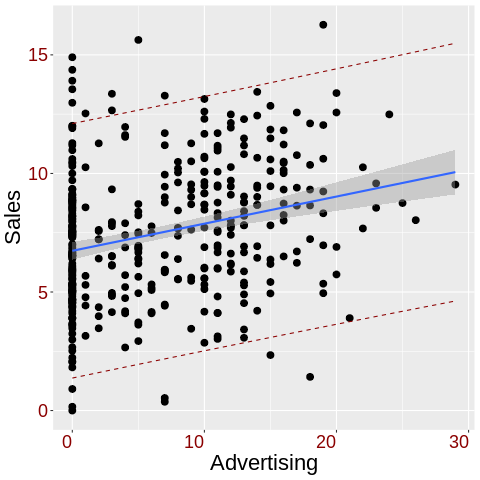

In [21]:
#create plot;
%%R


qplot(Advertising, Sales) + theme(axis.title.y = element_text(size = rel(2), angle = 90)) + theme(axis.title.x = element_text(size = rel(2), angle = 0))+ theme(axis.text.x = element_text(angle = 0, hjust = 1, size=18,color="darkred")) +  theme(axis.text.y = element_text(angle = 0, hjust = 1, size=18,color="darkred")) + geom_point(size = 3) + geom_smooth(method = "lm")+ geom_line(aes(y = all_data$lwr), col = "darkred", linetype = "dashed") + geom_line(aes(y = all_data$upr), col = "darkred", linetype = "dashed");

In [22]:
# Create SLR model for Sales vs. Advertising and name it “fit”;
%%R


fit <- lm(Sales ~ Advertising);

In [23]:
# Create 95% prediction interval for Sales for a store with Advertising = 20;
%%R


predict(fit, newdata = data.frame(Advertising = 20), interval = "predict");

       fit      lwr      upr
1 9.025917 3.638912 14.41292


In [24]:
# Create 95% confidence interval for Sales for a store with Advertising = 20;
%%R


predict(fit, newdata = data.frame(Advertising = 20), interval = "confidence");

       fit      lwr      upr
1 9.025917 8.424479 9.627355
